# NOVABANK ANALYTICS

**Project:** Analytics Methods & Frameworks (Quantic MSBA)

**Objective:** Build a predictive model to identify term deposit conversion prospects, optimizing call center capacity allocation.

## Project Phases:
1. **Problem Framing** (Conversion prediction, not churn; telemarketing campaign context)
2. **Data Readiness** (Preprocessing, feature engineering, train/test split)
3. **Model Building** (Baseline + Improved models with GridSearchCV)
4. **Decision Framework** (Threshold optimization, scenario testing, pilot plan)
5. **Delivery** (Executive memo, slides, reproducible notebook)

## 1: IMPORTS & SETUP

In [107]:
import pandas as pd
import numpy as np
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve, auc,
    precision_recall_curve, ConfusionMatrixDisplay)

import matplotlib.pyplot as plt

np.random.seed(42)

## 2: LOAD & EXPLORE DATA

In [108]:
csv_url = "https://raw.githubusercontent.com/Uzorah/Quantic-Nova-Bank-Project/refs/heads/main/bank-additional-full.csv"
df = pd.read_csv(csv_url, sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [109]:
print("Shape of dataframe\n", df.shape)

Shape of dataframe
 (41188, 21)


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [111]:
# Prercentage of Yes and No in target variable
df['y'].value_counts(normalize=True).map('{:.1%}'.format)

y
no     88.7%
yes    11.3%
Name: proportion, dtype: object

## 3. DATA PREPARATION

In [112]:
# Check for unknowns
for col in df.select_dtypes(include=['object', 'int64', 'float']).columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} ({unknown_count/len(df)*100:.1f}%)")

job: 330 (0.8%)
marital: 80 (0.2%)
education: 1731 (4.2%)
default: 8597 (20.9%)
housing: 990 (2.4%)
loan: 990 (2.4%)


In [113]:
# Dropping duration becaue of data leakage (it is only known after call)
df_clean = df.drop('duration', axis=1)

In [114]:
# renaming unknowns
categorical_cols = [col for col in df_clean.select_dtypes(include='object').columns if col != 'y']
for col in categorical_cols:
    df_clean[col] = df_clean[col].replace('unknown', f'{col}_unknown')

In [115]:
# dummy encode only the non-target categoricals
df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

In [116]:
# dummy encode target variable
df_clean['y'] = (df_clean['y'] == 'yes').astype(int)

In [117]:
df_clean.shape

(41188, 53)

In [118]:
# Create training and testing data
X = df_clean.drop('y', axis=1)
y = df_clean['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [119]:
#scaling training and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. BASELINE MODEL - LOGISTIC REGRESSION

In [120]:
# Train model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [121]:
#Predict on test set

y_pred = logreg.predict(X_test_scaled)
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]

In [122]:
unique_vals, counts = np.unique(y_pred, return_counts=True)

In [123]:
y_pred_proba

array([0.06942074, 0.02487254, 0.0587567 , ..., 0.06469485, 0.06874139,
       0.0405917 ])

In [124]:
# baseline metrics 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("BASELINE MODEL RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

BASELINE MODEL RESULTS
Accuracy:  0.9012
Precision: 0.6921
Recall:    0.2213
F1-Score:  0.3353
ROC-AUC:   0.8033



Confusion Matrix:
[[10828   137]
 [ 1084   308]]
True Negatives:  10828
False Positives: 137
False Negatives: 1084
True Positives:  308


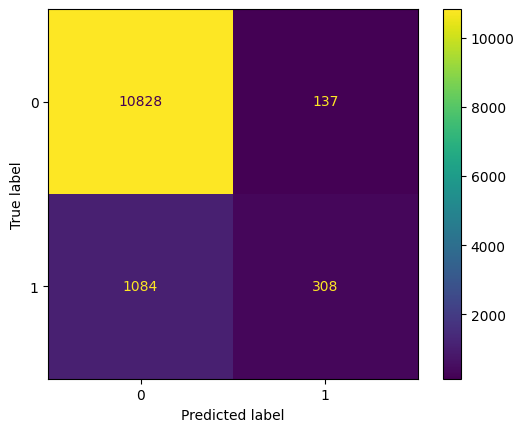

In [125]:
# 4. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)
print(f"True Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
cm_display.plot()
plt.show()

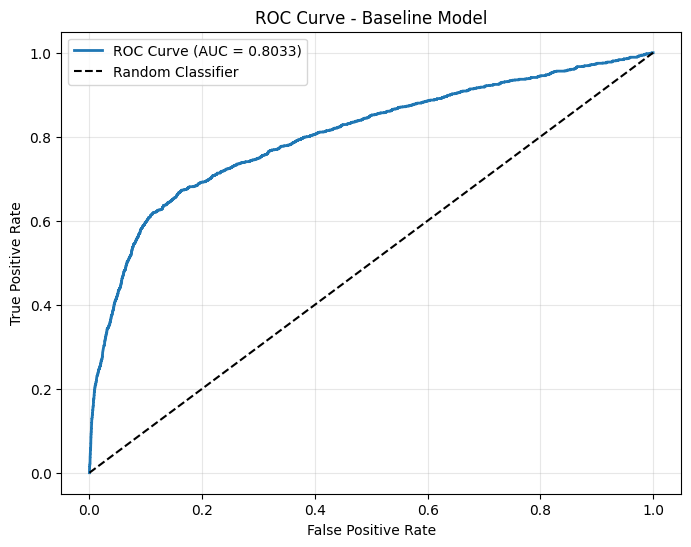

In [126]:
# 5. ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Model')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. IMPROVED MODELS - GRIDSEARCH

### 5.1 Random Forest with Gridsearch

In [127]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [5, 10],
    'min_samples_split': [10, 20],
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest RF parameters: {rf_grid.best_params_}")
print(f"Best RF CV F1-Score: {rf_grid.best_score_:.4f}")

# Get best model
rf_best = rf_grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best RF parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
Best RF CV F1-Score: 0.4947


### 5.2 XGBoost with Gridsearch

In [128]:
# Calculate scale_pos_weight to handle imbalance
# scale_pos_weight = (negative samples) / (positive samples)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nScale_pos_weight (for class imbalance): {scale_pos_weight:.2f}")

# Hyperparameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [scale_pos_weight]
}

# GridSearchCV with stratified cross-validation
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_scaled, y_train)

print(f"\nBest XGB parameters: {xgb_grid.best_params_}")
print(f"Best XGB CV F1-Score: {xgb_grid.best_score_:.4f}")

# Get best model
xgb_best = xgb_grid.best_estimator_


Scale_pos_weight (for class imbalance): 7.88
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best XGB parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 200, 'scale_pos_weight': 7.876539408866995, 'subsample': 0.8}
Best XGB CV F1-Score: 0.4825


## 6: MODEL COMPARISON & THRESHOLD ANALYSIS

In [129]:
models = {
    'Logistic Regression (Baseline)': logreg,
    'Random Forest (GridSearch)': rf_best,
    'XGBoost (GridSearch)': xgb_best
}

results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc})

# Create comparison table
results_df = pd.DataFrame(results)
print("COMPARISON TABLE")
results_df.style.format(precision=4).hide(axis='index')

COMPARISON TABLE


Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression (Baseline),0.9012,0.6921,0.2213,0.3353,0.8033
Random Forest (GridSearch),0.8704,0.4457,0.6164,0.5173,0.8085
XGBoost (GridSearch),0.8630,0.4258,0.6207,0.5051,0.8117


## FEATURE IMPORTANCE

### Feature Importance: Random Forest


Top 15 Features:
             feature  importance
           euribor3m    0.163876
        emp.var.rate    0.099004
         nr.employed    0.097309
                 age    0.094356
       cons.conf.idx    0.052556
            campaign    0.050663
      cons.price.idx    0.038089
               pdays    0.037024
    poutcome_success    0.024698
   contact_telephone    0.020649
           month_may    0.019092
          default_no    0.016586
poutcome_nonexistent    0.016369
            previous    0.014982
     marital_married    0.013815


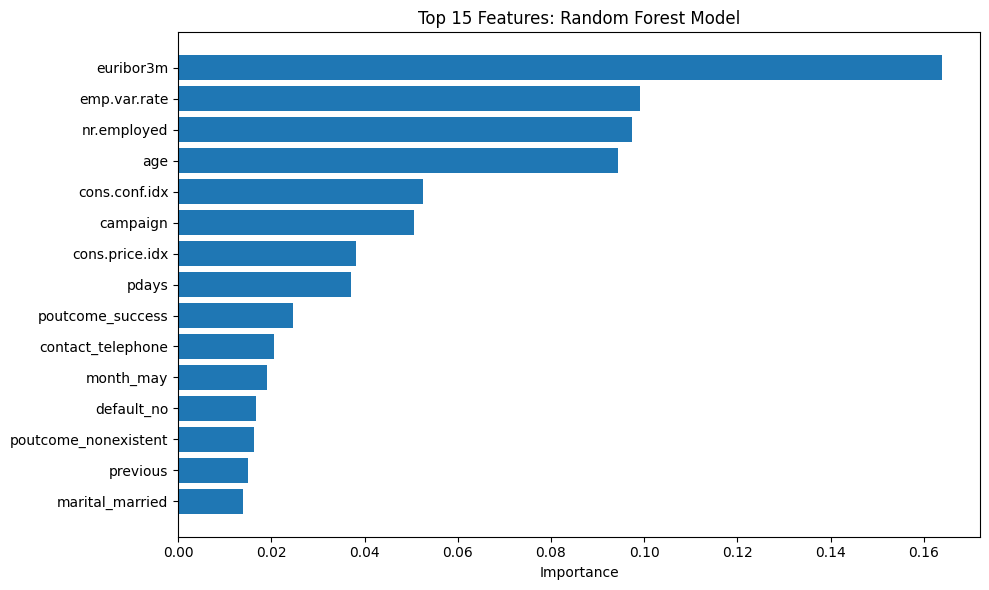

In [130]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Features:")
print(feature_importance.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Features: Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Feature Importance: XGBoost


Top 15 Features (XGBoost):
                feature  importance
            nr.employed    0.558768
           emp.var.rate    0.047395
          cons.conf.idx    0.040114
              month_may    0.034924
              month_oct    0.030018
              euribor3m    0.017506
       poutcome_success    0.014337
         cons.price.idx    0.013024
                  pdays    0.011337
marital_marital_unknown    0.010062
      contact_telephone    0.009854
             default_no    0.009213
              month_mar    0.007778
   poutcome_nonexistent    0.006977
            job_retired    0.006760


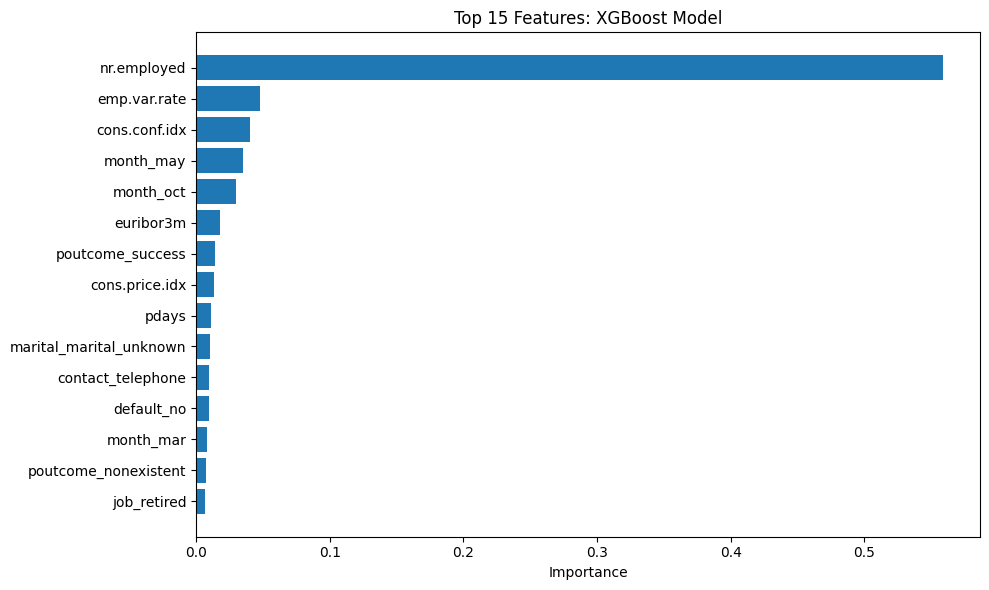

In [131]:
feature_importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Features (XGBoost):")
print(feature_importance_xgb.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
top_features_xgb = feature_importance_xgb.head(15)
plt.barh(range(len(top_features_xgb)), top_features_xgb['importance'])
plt.yticks(range(len(top_features_xgb)), top_features_xgb['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Features: XGBoost Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Threshold Analysis - Precisision vs Recall at multiple thresholds

In [132]:
for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Generate precision-recall curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
    
    print(f"\n{model_name}:")
    print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
    print("-" * 50)
    
    # Test a range of thresholds
    test_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]
    
    for threshold in test_thresholds:
        y_pred_threshold = (y_pred_proba >= threshold).astype(int)
        
        if y_pred_threshold.sum() == 0:  # No positive predictions
            print(f"{threshold:<12.2f} {'N/A':<12} {'0.0000':<12} {'N/A':<12}")
        else:
            prec = precision_score(y_test, y_pred_threshold, zero_division=0)
            rec = recall_score(y_test, y_pred_threshold, zero_division=0)
            f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
            print(f"{threshold:<12.2f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")


Logistic Regression (Baseline):
Threshold    Precision    Recall       F1          
--------------------------------------------------
0.30         0.5070       0.4404       0.4714      
0.40         0.5909       0.3175       0.4131      
0.50         0.6921       0.2213       0.3353      
0.60         0.7508       0.1731       0.2814      
0.70         0.7923       0.1042       0.1841      
0.75         0.7850       0.0603       0.1121      
0.80         0.8082       0.0424       0.0805      
0.85         0.8929       0.0180       0.0352      
0.90         N/A          0.0000       N/A         

Random Forest (GridSearch):
Threshold    Precision    Recall       F1          
--------------------------------------------------
0.30         0.2649       0.7385       0.3900      
0.40         0.3799       0.6523       0.4802      
0.50         0.4457       0.6164       0.5173      
0.60         0.4878       0.5596       0.5212      
0.70         0.5450       0.4397       0.4867      
0.75

## AI USAGE LOG

### PHASE 2: DATA PREPARATION  
Tool: Claude AI \
Task: Data preprocessing code guidance \
Contribution:
  - Identified duration column as data leakage risk
  - Suggested handling for 'unknown' values (rename vs. delete)
  - Recommended one-hot encoding with drop_first=True

### PHASE 3: BASELINE MODEL & GRIDSEARCH
Tool: Claude AI \
Task: Model code templates and GridSearchCV scaffolding \
Contribution:
  - Provided LogisticRegression baseline code structure
  - Generated GridSearchCV templates for Random Forest
  - Generated GridSearchCV templates for XGBoost with scale_pos_weight

### PHASE 4: THRESHOLD ANALYSIS
Tool: Claude AI \
Task: Threshold analysis code + interpretation \
Contribution:
  - Provided precision-recall curve analysis code
  - Suggested testing multiple thresholds (0.3 to 0.9)

### PHASE 5: FINANCIAL MODELING & ASSUMPTIONS
Tool: Gemini AI (Cost Research) \
Task: Industry research on typical cost per call \
Contribution:
  - Researched cost per call benchmarks across industries
  - Found: Banking & Finance €10-€25/call range
  - Recommended €15/call as conservative mid-range estimate

Tool: Claude AI \
Task: Financial impact calculation \
Contribution:
  - Structured cost-benefit analysis
  - Designed cost per conversion metric